# 04_SVM_With_DR

## SVM With PCA-Based Dimensionality Reduction

This notebook uses the already PCA-transformed features and does **not** recreate PCA.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

sns.set_style("whitegrid")
ROOT = Path.cwd()
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Results directory is ready.")

from sklearn.svm import SVC


Results directory is ready.


### Load PCA-Transformed Data and PCA Artifacts

In [2]:
X_train = pd.read_csv(ROOT / "SVM" / "train" / "x_train_svm_pca.csv")
X_test = pd.read_csv(ROOT / "SVM" / "test" / "x_test_svm_pca.csv")
y_train = pd.read_csv(ROOT / "SVM" / "train" / "y_train.csv").squeeze()
y_test = pd.read_csv(ROOT / "SVM" / "test" / "y_test.csv").squeeze()

pca_explained_variance = pd.read_csv(ROOT / "SVM" / "pca_explained_variance.csv")
pca_components = pd.read_csv(ROOT / "SVM" / "pca_components.csv")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("pca_explained_variance:", pca_explained_variance.shape)
print("pca_components:", pca_components.shape)


X_train: (4930, 17)
X_test: (2113, 17)
y_train: (4930,)
y_test: (2113,)
pca_explained_variance: (17, 3)
pca_components: (17, 31)


### PCA Explained Variance Summary

This experiment assumes PCA already preserved approximately 95% variance during prior preprocessing.

Limitation note: if PCA was created without scaling, this is a limitation because both PCA and SVM are sensitive to feature scaling.


In [3]:
print("PCA explained variance preview:")
print(pca_explained_variance.head(15).to_string(index=False))

numeric_cols = pca_explained_variance.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    summary = pca_explained_variance[numeric_cols].describe().T
    print("\nNumeric summary:")
    print(summary.to_string())
else:
    print("\nNo numeric columns detected in pca_explained_variance.csv; showing raw table only.")


PCA explained variance preview:
Principal Component  Explained Variance Ratio  Cumulative Explained Variance
                PC1                  0.395955                       0.395955
                PC2                  0.185182                       0.581137
                PC3                  0.061133                       0.642269
                PC4                  0.034971                       0.677240
                PC5                  0.033369                       0.710609
                PC6                  0.030514                       0.741123
                PC7                  0.028399                       0.769521
                PC8                  0.025972                       0.795493
                PC9                  0.024697                       0.820190
               PC10                  0.022869                       0.843059
               PC11                  0.018703                       0.861762
               PC12                  0.01860

### Train SVM on PCA Features

PCA can help SVM by reducing dimensionality, potentially removing noise, and making training more efficient.


In [4]:
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
}
metrics_df = pd.DataFrame([metrics])
metrics_path = RESULTS_DIR / "svm_with_dr_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

print("SVM With DR metrics:")
print(metrics_df.to_string(index=False))
print("\nSaved metrics CSV to results/.")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


SVM With DR metrics:
 Accuracy  Precision   Recall  F1-score
 0.797444   0.664198 0.479501  0.556936

Saved metrics CSV to results/.

Confusion Matrix:
[[1416  136]
 [ 292  269]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1552
           1       0.66      0.48      0.56       561

    accuracy                           0.80      2113
   macro avg       0.75      0.70      0.71      2113
weighted avg       0.79      0.80      0.79      2113



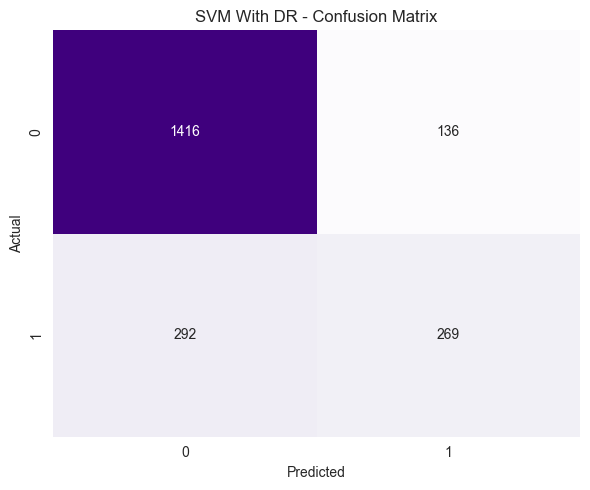

Saved confusion matrix plot to results/.


In [5]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("SVM With DR - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
cm_path = RESULTS_DIR / "svm_with_dr_confusion_matrix.png"
plt.tight_layout()
plt.savefig(cm_path, dpi=300)
plt.show()
print("Saved confusion matrix plot to results/.")


### Brief Comparison vs SVM Without DR

In [6]:
baseline_path = RESULTS_DIR / "svm_without_dr_metrics.csv"
if baseline_path.exists():
    baseline = pd.read_csv(baseline_path)
    baseline.insert(0, "Experiment", "SVM Without DR")
    current = metrics_df.copy()
    current.insert(0, "Experiment", "SVM With DR")
    comparison = pd.concat([baseline, current], ignore_index=True)
    print(comparison.to_string(index=False))
else:
    print("Baseline SVM metrics file not found yet. Run 03_SVM_Without_DR.ipynb first for comparison.")


    Experiment  Accuracy  Precision   Recall  F1-score
SVM Without DR  0.794132   0.647887 0.491979  0.559271
   SVM With DR  0.797444   0.664198 0.479501  0.556936


In [7]:
print("\nExperiment completed successfully.")
print("Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.")
print("Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.")



Experiment completed successfully.
Results (metrics CSV and confusion matrix plot) were saved in the results/ directory.
Use Accuracy, Precision, Recall, and F1-score together for balanced model evaluation.
